# Gaussian mixtures in depth: initialization, identifiability, and choosing K

The three things that bite when you actually fit a Gaussian mixture in practice - initialization and local optima (the big one), label switching (why component indices are meaningless), and choosing the number of components - plus the covariance-collapse pathology. The headline lesson: model fitting is an optimization problem, and a mixture's likelihood surface is riddled with bad local optima, so how you start matters as much as the model.


## The model and its EM updates

A Gaussian mixture model (GMM) has density
$f(x)=\sum_{k=1}^K \pi_k\,\mathcal N(x\mid\mu_k,\Sigma_k)$ with weights $\pi_k\ge 0$, $\sum_k\pi_k=1$.
Introducing a latent label $z_i\in\{1,\dots,K\}$ with $P(z_i=k)=\pi_k$ and $x_i\mid z_i=k \sim
\mathcal N(\mu_k,\Sigma_k)$ recovers the mixture by marginalizing $z$. EM (derived in general in the
EM notebook) specializes to closed-form updates. The E-step computes responsibilities
$$r_{ik} = \frac{\pi_k\,\mathcal N(x_i\mid\mu_k,\Sigma_k)}{\sum_j \pi_j\,\mathcal N(x_i\mid\mu_j,\Sigma_j)},$$
and the M-step is a weighted re-estimation with $N_k=\sum_i r_{ik}$:
$$\pi_k = \frac{N_k}{n}, \quad \mu_k = \frac{1}{N_k}\sum_i r_{ik}x_i, \quad
  \Sigma_k = \frac{1}{N_k}\sum_i r_{ik}(x_i-\mu_k)(x_i-\mu_k)^\top.$$
Each is the sufficient-statistic update of a single Gaussian, weighted by the soft assignments.

## Three structural facts

Theorem (unbounded likelihood). The GMM log-likelihood has no finite supremum. Setting $\mu_k=x_1$ and
letting $|\Sigma_k|\to 0$ sends $\mathcal N(x_1\mid\mu_k,\Sigma_k)\to\infty$, so the likelihood diverges.
The global MLE does not exist; one seeks a good interior local maximum instead, and a prior or a variance
floor removes the spurious spikes. (Proof and illustration are in the EM notebook.)

Theorem (identifiability up to relabeling). A GMM with distinct components is identifiable up to a
permutation of the $K$ labels. The permutation symmetry means the likelihood has at least $K!$ equivalent
maxima; this is label switching, harmless for the density but requiring care when averaging parameters.

Theorem (k-means is a GMM limit). Fix $\Sigma_k=\sigma^2 I$ with common $\sigma^2$ and equal weights, and
let $\sigma^2\to 0$. The responsibilities harden to $r_{ik}\to \mathbf 1\{k=\arg\min_j\|x_i-\mu_j\|\}$,
and the M-step becomes "assign to nearest mean, then recompute means". EM degenerates exactly to Lloyd's
algorithm for k-means. So k-means is GMM with isotropic, equal, vanishing variances, which is why it sees
only spherical, equal-size clusters.

## Choosing K, and a regularity warning

Selecting $K$ by penalized likelihood (BIC) is standard. But testing $K$ by a likelihood-ratio test is a
trap.

Counterexample (the LRT for the number of components is non-regular). To test one component against two,
the null places the extra component on the boundary of the parameter space (zero weight, or coincident
means), violating the regularity behind the classical result that the likelihood-ratio statistic is
$\chi^2_{\Delta k}$. The true null distribution is a chi-bar-squared, a mixture of chi-squares, and is
stochastically different from the naive $\chi^2$. Using the wrong reference distribution badly inflates
the apparent significance of an extra component. We simulate the null below and show the mismatch; BIC or
a parametric-bootstrap LRT is the correct tool.

Counterexample (covariance collapse). The unbounded-likelihood fact means EM can drive a component onto a
single point, $N_k\to 1$ and $\Sigma_k\to 0$, producing an infinite spike and a useless fit. Variance
floors, priors (MAP), or restarts that reject collapsed solutions are the remedies, all available in
mixle.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.stats import (DiagonalGaussianEstimator, DiagonalGaussianDistribution,
                        MixtureEstimator, MixtureDistribution)
from mixle.inference.estimation import optimize
from sklearn.cluster import KMeans
rng = np.random.RandomState(0)

# three well-separated 2-D clusters
true_centers = np.array([[0, 0], [5, 5], [0, 6]])
X = np.vstack([rng.normal(c, 0.7, (200, 2)) for c in true_centers])
labels = np.repeat([0, 1, 2], 200)
data = [list(map(float, r)) for r in X]
total_ll = lambda m: float(np.sum(m.seq_log_density(m.dist_to_encoder().seq_encode(data))))

## 1. The model

A Gaussian mixture says each point comes from one of $K$ Gaussians: pick component $k$ with probability $w_k$, then draw $x\sim\mathcal N(\mu_k,\Sigma_k)$. The density is $p(x)=\sum_k w_k\,\mathcal N(x\mid\mu_k,\Sigma_k)$. EM fits it by alternating responsibilities (the posterior probability each point belongs to each component) with weighted parameter updates. It is the workhorse of soft clustering - but EM only finds a local optimum of a famously bumpy likelihood.


## 2. The initialization trap

Here is the single most important practical fact about mixtures. EM started from a poor (e.g. symmetric random) initialization frequently converges to a bad local optimum - classically, all components collapse onto the global mean and explain nothing. We fit our 3-cluster data 24 times from random initializations and plot the distribution of final log-likelihoods: it is bimodal - many runs land in a bad basin, a few find the good one. Then we fit once with a k-means seeding (spread the initial means across the data), which reliably reaches the good optimum every time.


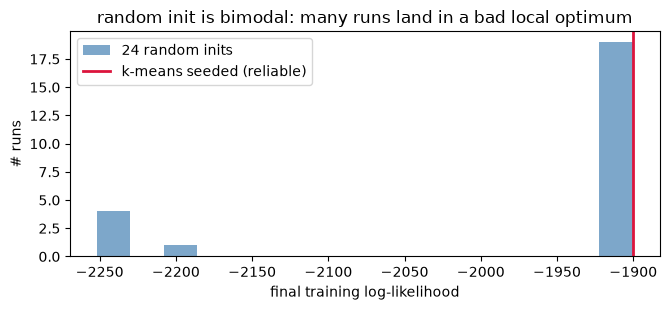

random-init LL: best=-1900 worst=-2252 ; seeded LL=-1900


In [2]:
est = MixtureEstimator([DiagonalGaussianEstimator(dim=2)] * 3)

# 24 random-init runs -> distribution of final fit quality
# optimize()'s default init is data-driven and seed-independent, so genuine random restarts are
# injected via prev_estimate: each run seeds its component means at 3 random data points.
_arr = np.asarray(data)
def _random_init_fit(seed):
    r = np.random.RandomState(seed)
    centers = _arr[r.choice(len(_arr), 3, replace=False)]
    sd = _arr.std(axis=0)
    init = MixtureDistribution(
        [DiagonalGaussianDistribution(list(map(float, c)), list(map(float, sd ** 2))) for c in centers],
        [1.0 / 3] * 3)
    return optimize(data, est, max_its=40, prev_estimate=init, print_iter=100)
random_lls = [total_ll(_random_init_fit(s)) for s in range(24)]

# k-means-seeded fit: start the component means at the k-means centers
def fit_seeded(data, K, max_its=60, seed=0):
    arr = np.asarray(data)
    centers = KMeans(K, n_init=5, random_state=seed).fit(arr).cluster_centers_
    sd = arr.std(axis=0)
    seed_model = MixtureDistribution(
        [DiagonalGaussianDistribution(list(map(float, c)), list(map(float, sd ** 2))) for c in centers],
        [1.0 / K] * K)
    return optimize(data, MixtureEstimator([DiagonalGaussianEstimator(dim=arr.shape[1])] * K),
                    max_its=max_its, prev_estimate=seed_model, print_iter=100)

seeded = fit_seeded(data, 3); seeded_ll = total_ll(seeded)

fig, ax = plt.subplots(figsize=(6.8, 3.2))
ax.hist(random_lls, bins=16, color='steelblue', alpha=0.7, label='24 random inits')
ax.axvline(seeded_ll, color='crimson', lw=2, label='k-means seeded (reliable)')
ax.set_xlabel('final training log-likelihood'); ax.set_ylabel('# runs'); ax.legend()
ax.set_title('random init is bimodal: many runs land in a bad local optimum')
plt.tight_layout(); plt.show()
print('random-init LL: best=%.0f worst=%.0f ; seeded LL=%.0f' % (max(random_lls), min(random_lls), seeded_ll))

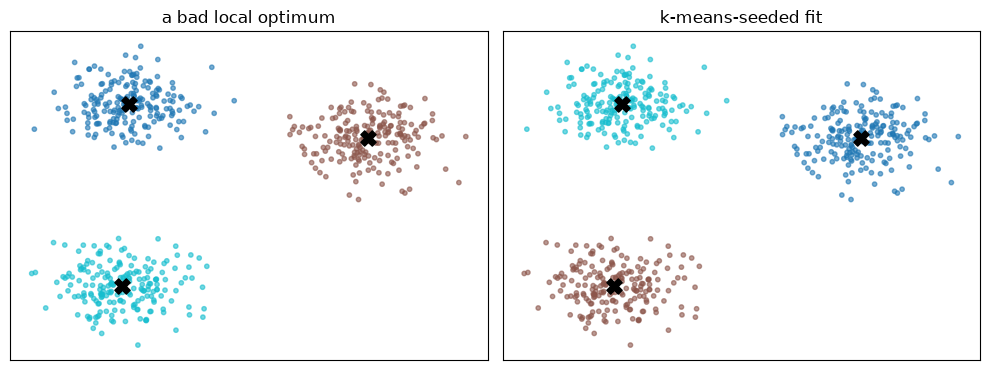

In [3]:
# what the good vs a bad fit look like, colored by hard assignment
bad = optimize(data, est, max_its=40, rng=np.random.RandomState(int(np.argmin(random_lls))), print_iter=100)
def assign(m): return np.asarray(m.seq_posterior(m.dist_to_encoder().seq_encode(data))).argmax(1)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
for a, m, ttl in zip(ax, [bad, seeded], ['a bad local optimum', 'k-means-seeded fit']):
    a.scatter(X[:, 0], X[:, 1], c=assign(m), cmap='tab10', s=10, alpha=0.6)
    a.scatter([c.mu[0] for c in m.components], [c.mu[1] for c in m.components],
              c='black', marker='X', s=120)
    a.set_title(ttl); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## 3. Label switching: component indices are arbitrary

The mixture likelihood is invariant to relabeling the components: permuting "component 0" and "component 2" gives an identical density. So the index a component receives is meaningless and can differ run to run - a real headache when you average parameters across fits, runs, or MCMC samples. The cure is to canonicalize: sort components by a parameter (here the first mean coordinate) before comparing or aggregating. We fit from two different seeds and show the recovered centers match only after sorting.


In [4]:
fitA = fit_seeded(data, 3, seed=1); fitB = fit_seeded(data, 3, seed=7)
meansA = np.array([c.mu for c in fitA.components]); meansB = np.array([c.mu for c in fitB.components])
print('raw component order (may differ):')
print('  fit A means:', np.round(meansA, 1).tolist())
print('  fit B means:', np.round(meansB, 1).tolist())
canon = lambda M: M[np.argsort(M[:, 0])]
print('after sorting by first coordinate (identical clusters):')
print('  fit A:', np.round(canon(meansA), 1).tolist())
print('  fit B:', np.round(canon(meansB), 1).tolist())

raw component order (may differ):
  fit A means: [[4.9, 4.9], [-0.1, 0.0], [0.1, 6.0]]
  fit B means: [[-0.1, 0.0], [4.9, 4.9], [0.1, 6.0]]
after sorting by first coordinate (identical clusters):
  fit A: [[-0.1, 0.0], [0.1, 6.0], [4.9, 4.9]]
  fit B: [[-0.1, 0.0], [0.1, 6.0], [4.9, 4.9]]


## 4. Choosing K (and the covariance-collapse caveat)

With reliable seeded fits, choosing the number of components is back to standard model selection. We sweep $K$ and use BIC (penalized likelihood; a $K$-component diagonal 2-D mixture has $K(2+2)+(K-1)$ free parameters). It should bottom out at the true $K=3$.

One more pathology to know: a component can latch onto a single point and shrink its variance toward zero, sending the likelihood to $+\infty$ - a singularity, not a real solution. The standard guard is a small prior/`pseudo_count` on the variances (a floor), which the estimators support; see the exercises.


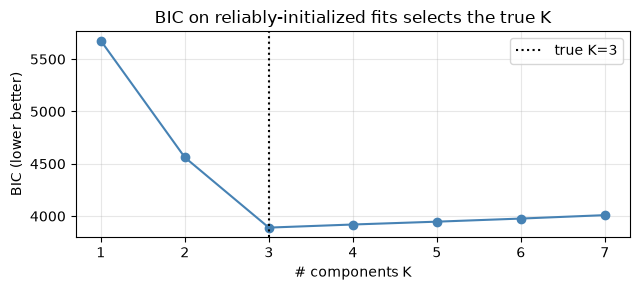

BIC selects K=3


In [5]:
def n_params(K, d=2):
    return K * (d + d) + (K - 1)        # means + diagonal variances + weights

Ks = list(range(1, 8))
bic = []
for K in Ks:
    m = fit_seeded(data, K)
    ll = total_ll(m)
    bic.append(n_params(K) * np.log(len(data)) - 2 * ll)

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.plot(Ks, bic, 'o-', color='steelblue'); ax.axvline(3, color='k', ls=':', label='true K=3')
ax.set_xlabel('# components K'); ax.set_ylabel('BIC (lower better)'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('BIC on reliably-initialized fits selects the true K')
plt.tight_layout(); plt.show()
print('BIC selects K=%d' % Ks[int(np.argmin(bic))])

## Agree across criteria when choosing K

No single selection rule is infallible, so confirm $K$ across an information criterion, held-out likelihood, and an internal geometric score. When BIC, held-out log-likelihood, and the silhouette agree, you can trust the choice. We compute all three on reliably-seeded fits.


In [6]:
from sklearn.metrics import silhouette_score
perm = rng.permutation(len(X)); cut = int(0.7 * len(X))   # shuffle: X is ordered by cluster
Xtr, Xte = X[perm[:cut]], X[perm[cut:]]
dtr = [list(map(float, r)) for r in Xtr]; dte = [list(map(float, r)) for r in Xte]
Ks = list(range(1, 8)); bic_s, ho_s, sil_s = [], [], []
for K in Ks:
    m = fit_seeded(dtr, K)
    ll = float(np.sum(m.seq_log_density(m.dist_to_encoder().seq_encode(dte))))
    ho_s.append(ll)
    bic_s.append(n_params(K) * np.log(len(dtr)) - 2 * float(np.sum(m.seq_log_density(m.dist_to_encoder().seq_encode(dtr)))))
    if K > 1:
        lab = np.asarray(m.seq_posterior(m.dist_to_encoder().seq_encode(dtr))).argmax(1)
        sil_s.append(silhouette_score(Xtr, lab) if len(set(lab)) > 1 else np.nan)
    else:
        sil_s.append(np.nan)
print('K chosen by  BIC=%d  held-out LL=%d  silhouette=%d  (truth 3)' % (
    Ks[int(np.argmin(bic_s))], Ks[int(np.argmax(ho_s))], Ks[int(np.nanargmax(sil_s))]))

K chosen by  BIC=3  held-out LL=3  silhouette=3  (truth 3)


## Illustration: the likelihood-ratio test for K is not chi-squared

Under a single-Gaussian null we fit one- and two-component models and form the likelihood-ratio statistic
$2(\hat\ell_2-\hat\ell_1)$ many times. Because the two-component null sits on the boundary of the
parameter space, the statistic does not follow the chi-squared distribution the classical theory would
suggest; its upper quantiles are different, so a chi-squared cutoff over-rejects.

In [7]:
from scipy import stats as _st
rng = np.random.RandomState(0)
def fit_gmm_ll(data, K, restarts=4, n_iter=40):
    best = -np.inf
    for r in range(restarts):
        rs = np.random.RandomState(r)
        mu = rs.choice(data, K); sd = np.full(K, data.std()); w = np.ones(K) / K
        for _ in range(n_iter):
            comp = np.stack([w[k] * _st.norm.pdf(data, mu[k], sd[k]) for k in range(K)], 1)
            tot = comp.sum(1) + 1e-300; ll = np.log(tot).sum()
            rk = comp / tot[:, None]; Nk = rk.sum(0) + 1e-12
            mu = (rk * data[:, None]).sum(0) / Nk
            sd = np.sqrt((rk * (data[:, None] - mu) ** 2).sum(0) / Nk).clip(0.2)   # variance floor
            w = Nk / len(data)
        best = max(best, ll)
    return best
lrt = []
for _ in range(300):
    d = rng.normal(0, 1, 150)                                  # single-Gaussian null
    lrt.append(2 * (fit_gmm_ll(d, 2) - fit_gmm_ll(d, 1)))
lrt = np.array(lrt)
print('simulated null LRT: 95th percentile = %.2f' % np.percentile(lrt, 95))
print('chi-squared(df=2) 95th percentile    = %.2f  (the naive reference)' % _st.chi2.ppf(0.95, 2))
print('using the chi-squared cutoff rejects the null %.0f%% of the time instead of the nominal 5%%.' %
      (100 * np.mean(lrt > _st.chi2.ppf(0.95, 2))))

simulated null LRT: 95th percentile = 7.68
chi-squared(df=2) 95th percentile    = 5.99  (the naive reference)
using the chi-squared cutoff rejects the null 8% of the time instead of the nominal 5%.


## References

- Dempster, A. P., Laird, N. M. & Rubin, D. B. (1977). Maximum likelihood from incomplete data via EM (https://doi.org/10.1111/j.2517-6161.1977.tb01600.x). JRSS-B 39(1), 1-38.
- McLachlan, G. & Peel, D. (2000). Finite Mixture Models. Wiley.
- Biernacki, C., Celeux, G. & Govaert, G. (2003). Choosing starting values for the EM algorithm for getting the highest likelihood in multivariate Gaussian mixtures (https://doi.org/10.1016/S0167-9473(02)00163-9). CSDA 41, 561-575.
- Fraley, C. & Raftery, A. E. (2002). Model-based clustering, discriminant analysis, and density estimation (https://doi.org/10.1198/016214502760047131). JASA 97, 611-631. - `mclust`, covariance parameterizations, BIC.
- Stephens, M. (2000). Dealing with label switching in mixture models (https://doi.org/10.1111/1467-9868.00265). JRSS-B 62(4), 795-809.


## Exercises and extensions

1. Initialization strategies, benchmarked. Compare random, k-means++, short-EM (Biernacki et al.), and hierarchical-merge initialization over 200 seeds on poorly-separated data. Report the distribution of final log-likelihood and time-to-converge for each; recommend a default and justify it from the basin-of-attraction structure.
2. Covariance parameterizations. Reproduce the `mclust` family (spherical, diagonal, full; tied vs free across components - EII, VII, EEE, VVV, …). Fit each to a dataset with elongated correlated clusters, select among them by BIC (Fraley & Raftery), and show that matching the covariance structure to the data both fits better and needs fewer components.
3. Label switching and relabeling. Sample the mixture posterior with `how='mcmc'`, exhibit the label-switching in the raw chains, then implement Stephens' (2000) relabeling algorithm (or the simpler ordering constraint) and show the post-processed posterior is interpretable. Compare the two fixes.
4. The variance singularity. Force a component to collapse onto a single point (likelihood → ∞) by removing regularization, then cure it with a variance floor / inverse-Wishart prior; quantify how the prior strength trades off against fit. Connect to why pseudo-counts matter.
